In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# True parameters
true_mean = 50
true_variance = 25
true_std = np.sqrt(true_variance)

# Generate dataset
data = np.random.normal(
    loc=true_mean,
    scale=true_std,
    size=1000
)

print("True Mean     :", true_mean)
print("True Variance :", true_variance)
print("First 10 values:")
print(data[:10])

True Mean     : 50
True Variance : 25
First 10 values:
[52.48357077 49.30867849 53.23844269 57.61514928 48.82923313 48.82931522
 57.89606408 53.83717365 47.65262807 52.71280022]


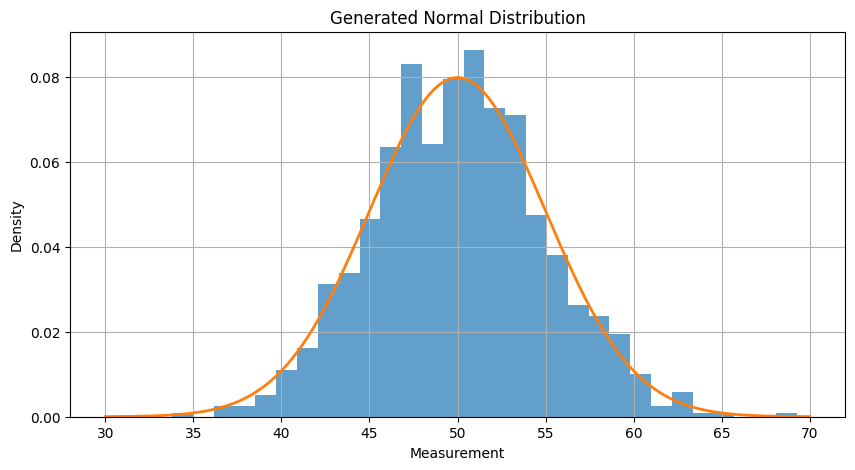

In [3]:
plt.figure(figsize=(10, 5))

plt.hist(data, bins=30, density=True, alpha=0.7)

x = np.linspace(30, 70, 500)
plt.plot(
    x,
    norm.pdf(x, true_mean, true_std),
    linewidth=2
)

plt.xlabel("Measurement")
plt.ylabel("Density")
plt.title("Generated Normal Distribution")
plt.grid(True)
plt.show()

In [4]:
def mle_estimation(data):
    mean_mle = np.mean(data)

    # MLE variance uses N, not N-1
    variance_mle = np.mean(
        (data - mean_mle) ** 2
    )

    return mean_mle, variance_mle

In [5]:
# Small sample
small_sample = data[:10]

# Large sample
large_sample = data[:500]

small_mean_mle, small_var_mle = mle_estimation(
    small_sample
)

large_mean_mle, large_var_mle = mle_estimation(
    large_sample
)

print("MLE Results")
print("--------------------------")

print("\nSmall Sample (n=10)")
print("Mean     :", small_mean_mle)
print("Variance :", small_var_mle)

print("\nLarge Sample (n=500)")
print("Mean     :", large_mean_mle)
print("Variance :", large_var_mle)

MLE Results
--------------------------

Small Sample (n=10)
Mean     : 52.24030555849379
Variance : 11.761673630328913

Large Sample (n=500)
Mean     : 50.03418997294323
Variance : 24.023305489681647


In [6]:
def bayesian_mean_estimation(
    data,
    prior_mean,
    prior_variance,
    known_variance
):

    n = len(data)
    sample_mean = np.mean(data)

    posterior_variance = 1 / (
        (n / known_variance) +
        (1 / prior_variance)
    )

    posterior_mean = posterior_variance * (
        (n * sample_mean / known_variance) +
        (prior_mean / prior_variance)
    )

    return posterior_mean, posterior_variance

In [7]:
prior_mean = 50
prior_variance = 100

# Bayesian estimation - small sample
bayes_small_mean, bayes_small_var = \
    bayesian_mean_estimation(
        small_sample,
        prior_mean,
        prior_variance,
        true_variance
    )

# Bayesian estimation - large sample
bayes_large_mean, bayes_large_var = \
    bayesian_mean_estimation(
        large_sample,
        prior_mean,
        prior_variance,
        true_variance
    )

print("Bayesian Estimation")
print("--------------------------")

print("\nSmall Sample (n=10)")
print("Posterior Mean     :", bayes_small_mean)
print("Posterior Variance :", bayes_small_var)

print("\nLarge Sample (n=500)")
print("Posterior Mean     :", bayes_large_mean)
print("Posterior Variance :", bayes_large_var)

Bayesian Estimation
--------------------------

Small Sample (n=10)
Posterior Mean     : 52.18566395950614
Posterior Variance : 2.4390243902439024

Large Sample (n=500)
Posterior Mean     : 50.03417288649998
Posterior Variance : 0.04997501249375312


In [8]:
prior_means = [40, 50, 60]
prior_variance = 100

results = []

for prior in prior_means:

    # Small sample
    small_bayes_mean, _ = bayesian_mean_estimation(
        small_sample,
        prior,
        prior_variance,
        true_variance
    )

    # Large sample
    large_bayes_mean, _ = bayesian_mean_estimation(
        large_sample,
        prior,
        prior_variance,
        true_variance
    )

    results.append([
        prior,
        small_bayes_mean,
        large_bayes_mean
    ])

prior_results = pd.DataFrame(
    results,
    columns=[
        "Prior Mean",
        "Bayesian Mean (n=10)",
        "Bayesian Mean (n=500)"
    ]
)

prior_results

,Prior Mean,Bayesian Mean (n=10),Bayesian Mean (n=500)
0,40,51.941762,50.029175
1,50,52.185664,50.034173
2,60,52.429566,50.039170


In [9]:
comparison = pd.DataFrame({
    "Method": [
        "True Parameter",
        "MLE",
        "Bayesian"
    ],

    "Small Sample Mean": [
        true_mean,
        small_mean_mle,
        bayes_small_mean
    ],

    "Large Sample Mean": [
        true_mean,
        large_mean_mle,
        bayes_large_mean
    ],

    "Small Sample Variance": [
        true_variance,
        small_var_mle,
        bayes_small_var
    ],

    "Large Sample Variance": [
        true_variance,
        large_var_mle,
        bayes_large_var
    ]
})

comparison

,Method,Small Sample Mean,Large Sample Mean,Small Sample Variance,Large Sample Variance
0,True Parameter,50.000000,50.000000,25.000000,25.000000
1,MLE,52.240306,50.034190,11.761674,24.023305
2,Bayesian,52.185664,50.034173,2.439024,0.049975


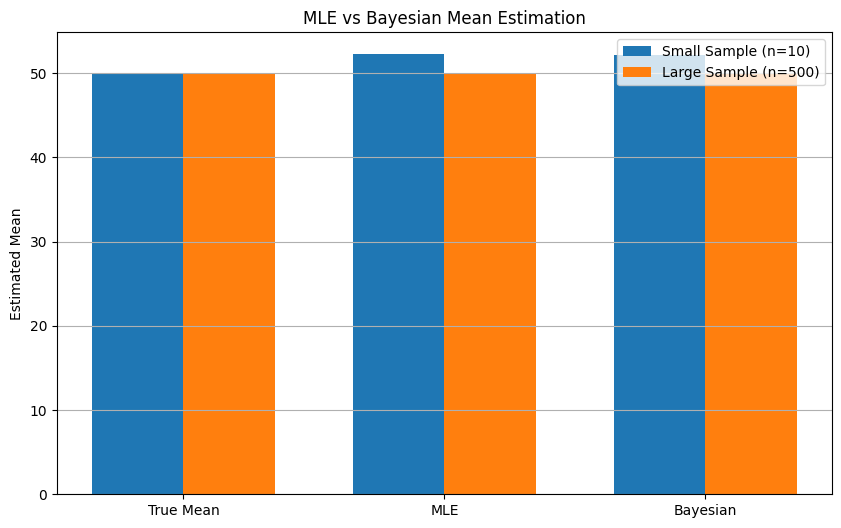

In [10]:
methods = [
    "True Mean",
    "MLE",
    "Bayesian"
]

small_values = [
    true_mean,
    small_mean_mle,
    bayes_small_mean
]

large_values = [
    true_mean,
    large_mean_mle,
    bayes_large_mean
]

x = np.arange(len(methods))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    small_values,
    width,
    label="Small Sample (n=10)"
)

plt.bar(
    x + width/2,
    large_values,
    width,
    label="Large Sample (n=500)"
)

plt.xticks(x, methods)
plt.ylabel("Estimated Mean")
plt.title("MLE vs Bayesian Mean Estimation")
plt.legend()
plt.grid(axis="y")

plt.show()

In [11]:
prior_variances = [10, 100, 1000]

prior_mean = 40

results = []

for pv in prior_variances:

    posterior_mean, posterior_variance = \
        bayesian_mean_estimation(
            small_sample,
            prior_mean,
            pv,
            true_variance
        )

    results.append([
        pv,
        posterior_mean,
        posterior_variance
    ])

prior_strength_df = pd.DataFrame(
    results,
    columns=[
        "Prior Variance",
        "Posterior Mean",
        "Posterior Variance"
    ]
)

prior_strength_df

,Prior Variance,Posterior Mean,Posterior Variance
0,10,49.792244,2.000000
1,100,51.941762,2.439024
2,1000,52.209781,2.493766


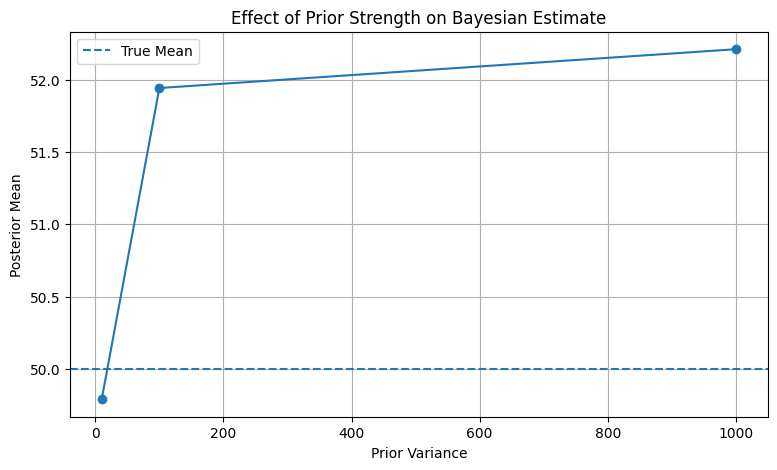

In [12]:
plt.figure(figsize=(9, 5))

plt.plot(
    prior_strength_df["Prior Variance"],
    prior_strength_df["Posterior Mean"],
    marker="o"
)

plt.axhline(
    true_mean,
    linestyle="--",
    label="True Mean"
)

plt.xlabel("Prior Variance")
plt.ylabel("Posterior Mean")
plt.title("Effect of Prior Strength on Bayesian Estimate")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
mle_small_error = abs(
    small_mean_mle - true_mean
)

mle_large_error = abs(
    large_mean_mle - true_mean
)

bayes_small_error = abs(
    bayes_small_mean - true_mean
)

bayes_large_error = abs(
    bayes_large_mean - true_mean
)

error_table = pd.DataFrame({
    "Method": [
        "MLE",
        "Bayesian"
    ],
    "Small Sample Error": [
        mle_small_error,
        bayes_small_error
    ],
    "Large Sample Error": [
        mle_large_error,
        bayes_large_error
    ]
})

error_table

,Method,Small Sample Error,Large Sample Error
0,MLE,2.240306,0.034190
1,Bayesian,2.185664,0.034173


In [14]:
print("========== FINAL RESULTS ==========")

print("\nTrue Parameters")
print("Mean     :", true_mean)
print("Variance :", true_variance)

print("\n----- MLE -----")

print("Small Sample:")
print("Mean     :", small_mean_mle)
print("Variance :", small_var_mle)

print("\nLarge Sample:")
print("Mean     :", large_mean_mle)
print("Variance :", large_var_mle)

print("\n----- BAYESIAN -----")

print("Small Sample:")
print("Mean     :", bayes_small_mean)
print("Posterior Variance :", bayes_small_var)

print("\nLarge Sample:")
print("Mean     :", bayes_large_mean)
print("Posterior Variance :", bayes_large_var)

========== FINAL RESULTS ==========

True Parameters
Mean     : 50
Variance : 25

----- MLE -----
Small Sample:
Mean     : 52.24030555849379
Variance : 11.761673630328913

Large Sample:
Mean     : 50.03418997294323
Variance : 24.023305489681647

----- BAYESIAN -----
Small Sample:
Mean     : 52.18566395950614
Posterior Variance : 2.4390243902439024

Large Sample:
Mean     : 50.03417288649998
Posterior Variance : 0.04997501249375312
